# Analyse Complète du Dataset Téléphones Mobiles

## Introduction
Ce notebook présente une analyse statistique complète d'un dataset de téléphones mobiles contenant 20 caractéristiques techniques et une variable cible de classification de prix (0-3).

---

In [1]:
# ============================================
# IMPORTS - Importation des bibliothèques nécessaires
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, mannwhitneyu, f_oneway, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

---

## 1. CHARGEMENT ET EXPLORATION DES DONNÉES

### 1.1 Chargement du dataset
Nous chargeons l'ensemble de données et affichons les premières lignes pour découvrir sa structure.

In [2]:
# Chargement du dataset
df = pd.read_csv('train.csv')

# Affichage des premières lignes
print("=" * 80)
print("PREMIÈRES LIGNES DU DATASET")
print("=" * 80)
display(df.head(10))

PREMIÈRES LIGNES DU DATASET


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,7,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,10,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,0,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,14,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,15,1137,1224,513,19,10,12,1,0,0,0


### 1.2 Résumé de la structure du dataset
Exploration des dimensions, types de données et informations générales.

In [3]:
# Informations générales sur le dataset
print("\n" + "=" * 80)
print("INFORMATION SUR LA STRUCTURE DU DATASET")
print("=" * 80)
print(f"\nDimensions du dataset: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nNoms et types des colonnes:")
print(df.dtypes)

print("\n" + "=" * 80)
print("ANALYSE DÉTAILLÉE DES DONNÉES")
print("=" * 80)
print(f"\nInfo globale sur le dataset:")
df.info()


INFORMATION SUR LA STRUCTURE DU DATASET

Dimensions du dataset: 2000 lignes × 21 colonnes

Noms et types des colonnes:
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

ANALYSE DÉTAILLÉE DES DONNÉES

Info globale sur le dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clo

### 1.3 Statistiques descriptives
Vue d'ensemble des statistiques de base pour chaque variable.

In [4]:
# Statistiques descriptives
print("\n" + "=" * 80)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 80)
descriptive_stats = df.describe().T
display(descriptive_stats)

# Analyse de la variable cible
print("\n" + "=" * 80)
print("DISTRIBUTION DE LA VARIABLE CIBLE (price_range)")
print("=" * 80)
target_counts = df['price_range'].value_counts().sort_index()
print(f"\nDistribution des prix:")
print(target_counts)
print(f"\nPourcentages:")
print((target_counts / len(df) * 100).round(2))


STATISTIQUES DESCRIPTIVES


,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0



DISTRIBUTION DE LA VARIABLE CIBLE (price_range)

Distribution des prix:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

Pourcentages:
price_range
0    25.0
1    25.0
2    25.0
3    25.0
Name: count, dtype: float64


---

## 2. NETTOYAGE ET PRÉTRAITEMENT DES DONNÉES

### 2.1 Détection des valeurs manquantes
Vérification et traitement des données nulles ou manquantes.

In [5]:
# Analyse des valeurs manquantes
print("\n" + "=" * 80)
print("DÉTECTION DES VALEURS MANQUANTES")
print("=" * 80)

missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Colonnes': df.columns,
    'Valeurs manquantes': missing_values.values,
    'Pourcentage': missing_percent.values
})

print(f"\nNombre total de valeurs manquantes: {df.isnull().sum().sum()}")
print("\nDétail par colonne:")
display(missing_df[missing_df['Valeurs manquantes'] > 0])

if df.isnull().sum().sum() == 0:
    print("\n✓ Aucune valeur manquante détectée. Les données sont complètes.")
else:
    print("\nTraitement des valeurs manquantes si nécessaire...")


DÉTECTION DES VALEURS MANQUANTES

Nombre total de valeurs manquantes: 0

Détail par colonne:


,Colonnes,Valeurs manquantes,Pourcentage



✓ Aucune valeur manquante détectée. Les données sont complètes.


### 2.2 Vérification des doublons et valeurs aberrantes
Détection des lignes en doublon et analyse des valeurs extrêmes.

In [6]:
# Détection des doublons
print("\n" + "=" * 80)
print("VÉRIFICATION DES DOUBLONS")
print("=" * 80)

n_duplicates = df.duplicated().sum()
print(f"Nombre de lignes en doublon: {n_duplicates}")

if n_duplicates > 0:
    df_cleaned = df.drop_duplicates()
    print(f"Lignes suppresssion: {n_duplicates}")
    print(f"Nouvelles dimensions: {df_cleaned.shape}")
else:
    print("✓ Aucun doublon détecté.")
    df_cleaned = df.copy()

# Analyse des valeurs aberrantes (Outliers)
print("\n" + "=" * 80)
print("ANALYSE DES VALEURS ABERRANTES (Outliers)")
print("=" * 80)

def detect_outliers(data, column):
    """Détecte les valeurs aberrantes en utilisant la méthode IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Identifier les colonnes numériques (exclure la cible)
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col != 'price_range']

outlier_counts = {}
for col in numeric_cols:
    outliers = detect_outliers(df_cleaned, col)
    outlier_counts[col] = outliers.sum()

print(f"\nNombre de valeurs aberrantes par colonne:")
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Colonne', 'Nombre d\'outliers'])
outlier_df = outlier_df[outlier_df['Nombre d\'outliers'] > 0].sort_values('Nombre d\'outliers', ascending=False)
display(outlier_df)

if len(outlier_df) > 0:
    print(f"\nRemarque: Les valeurs aberrantes sont conservées car elles peuvent être représentatives des données réelles.")
else:
    print("\n✓ Peu ou pas de valeurs aberrantes détectées.")


VÉRIFICATION DES DOUBLONS
Nombre de lignes en doublon: 0
✓ Aucun doublon détecté.

ANALYSE DES VALEURS ABERRANTES (Outliers)

Nombre de valeurs aberrantes par colonne:


,Colonne,Nombre d'outliers
17,three_g,477
4,fc,18
11,px_height,2



Remarque: Les valeurs aberrantes sont conservées car elles peuvent être représentatives des données réelles.


### 2.3 Transformation des variables catégorielles
Conversion des variables catégorielles en format numérique si nécessaire.

In [7]:
# Vérification des types de données et transformation catégorique
print("\n" + "=" * 80)
print("ANALYSE DES VARIABLES CATÉGORIELLES")
print("=" * 80)

categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
print(f"\nVariables catégorielles détectées: {list(categorical_cols) if len(categorical_cols) > 0 else 'Aucune'}")

if len(categorical_cols) == 0:
    print("\n✓ Le dataset ne contient pas de variables catégorielles.")
    print("Toutes les variables sont numériques et prêtes pour l'analyse.")
else:
    print("\nTransformation des variables catégorielles en numériques...")
    # Appliquer le one-hot encoding ou label encoding si nécessaire
    df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)
    print("✓ Transformation complétée.")

# Résumé final après nettoyage
print("\n" + "=" * 80)
print("RÉSUMÉ APRÈS NETTOYAGE ET PRÉTRAITEMENT")
print("=" * 80)
print(f"Dimensions finales: {df_cleaned.shape[0]} lignes × {df_cleaned.shape[1]} colonnes")
print(f"Nombre de variables numériques: {len(df_cleaned.select_dtypes(include=[np.number]).columns)}")
print("✓ Données prêtes pour l'analyse statistique.")


ANALYSE DES VARIABLES CATÉGORIELLES

Variables catégorielles détectées: Aucune

✓ Le dataset ne contient pas de variables catégorielles.
Toutes les variables sont numériques et prêtes pour l'analyse.

RÉSUMÉ APRÈS NETTOYAGE ET PRÉTRAITEMENT
Dimensions finales: 2000 lignes × 21 colonnes
Nombre de variables numériques: 21
✓ Données prêtes pour l'analyse statistique.


---

## 3. ANALYSE STATISTIQUE APPROFONDIE (NumPy et SciPy)

### 3.1 Mesures de tendance centrale et de variabilité
Calcul de la moyenne, médiane, mode, variance, écart-type et étendue.

In [8]:
# Analyse statistique détaillée par caractéristique
print("\n" + "=" * 80)
print("MESURES DE TENDANCE CENTRALE ET DE VARIABILITÉ")
print("=" * 80)

# Sélectionner uniquement les colonnes numériques (excluant la cible)
features = [col for col in df_cleaned.columns if col != 'price_range']

# Créer un dictionnaire pour stocker les statistiques
statistical_summary = {
    'Caractéristique': [],
    'Moyenne': [],
    'Médiane': [],
    'Mode': [],
    'Écart-type': [],
    'Variance': [],
    'Étendue': [],
    'Min': [],
    'Max': []
}

for feature in features:
    data = df_cleaned[feature].dropna()
    
    statistical_summary['Caractéristique'].append(feature)
    statistical_summary['Moyenne'].append(np.mean(data))
    statistical_summary['Médiane'].append(np.median(data))
    
    # Calculer le mode
    mode_value = stats.mode(data, keepdims=True)[0][0]
    statistical_summary['Mode'].append(mode_value)
    
    statistical_summary['Écart-type'].append(np.std(data))
    statistical_summary['Variance'].append(np.var(data))
    statistical_summary['Étendue'].append(np.max(data) - np.min(data))
    statistical_summary['Min'].append(np.min(data))
    statistical_summary['Max'].append(np.max(data))

stats_df = pd.DataFrame(statistical_summary)

print("\nRésumé statistique (premiers 10 features):")
display(stats_df.head(10).round(2))

print("\nRésumé statistique (derniers 10 features):")
display(stats_df.tail(10).round(2))


MESURES DE TENDANCE CENTRALE ET DE VARIABILITÉ

Résumé statistique (premiers 10 features):


,Caractéristique,Moyenne,Médiane,Mode,Écart-type,Variance,Étendue,Min,Max
0,battery_power,1238.52,1226.0,618.0,439.31,192991.82,1497.0,501.0,1998.0
1,blue,0.50,0.0,0.0,0.50,0.25,1.0,0.0,1.0
2,clock_speed,1.52,1.5,0.5,0.82,0.67,2.5,0.5,3.0
3,dual_sim,0.51,1.0,1.0,0.50,0.25,1.0,0.0,1.0
4,fc,4.31,3.0,0.0,4.34,18.84,19.0,0.0,19.0
5,four_g,0.52,1.0,1.0,0.50,0.25,1.0,0.0,1.0
6,int_memory,32.05,32.0,27.0,18.14,329.10,62.0,2.0,64.0
7,m_dep,0.50,0.5,0.1,0.29,0.08,0.9,0.1,1.0
8,mobile_wt,140.25,141.0,182.0,35.39,1252.51,120.0,80.0,200.0
9,n_cores,4.52,4.0,4.0,2.29,5.23,7.0,1.0,8.0



Résumé statistique (derniers 10 features):


,Caractéristique,Moyenne,Médiane,Mode,Écart-type,Variance,Étendue,Min,Max
10,pc,9.92,10.0,10.0,6.06,36.76,20.0,0.0,20.0
11,px_height,645.11,564.0,347.0,443.67,196842.94,1960.0,0.0,1960.0
12,px_width,1251.52,1247.0,874.0,432.09,186702.96,1498.0,500.0,1998.0
13,ram,2124.21,2146.5,1229.0,1084.46,1176055.28,3742.0,256.0,3998.0
14,sc_h,12.31,12.0,17.0,4.21,17.74,14.0,5.0,19.0
15,sc_w,5.77,5.0,1.0,4.36,18.97,18.0,0.0,18.0
16,talk_time,11.01,11.0,7.0,5.46,29.84,18.0,2.0,20.0
17,three_g,0.76,1.0,1.0,0.43,0.18,1.0,0.0,1.0
18,touch_screen,0.50,1.0,1.0,0.50,0.25,1.0,0.0,1.0
19,wifi,0.51,1.0,1.0,0.50,0.25,1.0,0.0,1.0


### 3.2 Analyse de la forme des distributions
Calcul de l'asymétrie (skewness) et de l'aplatissement (kurtosis).

In [9]:
# Analyse de l'asymétrie et du kurtosis
print("\n" + "=" * 80)
print("ANALYSE DE LA FORME DES DISTRIBUTIONS (Asymétrie et Kurtosis)")
print("=" * 80)
print("\nInterprétation:")
print("- Asymétrie (Skewness): ")
print("  * ≈ 0: Distribution symétrique")
print("  * > 0: Distribution asymétrique à droite (queue à droite)")
print("  * < 0: Distribution asymétrique à gauche (queue à gauche)")
print("- Kurtosis: Mesure l'aplatissement de la distribution")
print("  * ≈ 0 (excès Kurtosis): Distribution normale")
print("  * > 0: Distribution plus pointue (leptokurtique)")
print("  * < 0: Distribution plus plate (platykurtique)")

skewness_kurtosis = {
    'Caractéristique': [],
    'Asymétrie (Skewness)': [],
    'Kurtosis': [],
    'Interprétation Asymétrie': [],
    'Interprétation Kurtosis': []
}

for feature in features:
    data = df_cleaned[feature].dropna()
    
    skew_value = skew(data)
    kurt_value = kurtosis(data)
    
    # Interprétation
    if abs(skew_value) < 0.5:
        skew_interp = "Symétrique"
    elif skew_value > 0:
        skew_interp = "Asymétrie à droite"
    else:
        skew_interp = "Asymétrie à gauche"
    
    if abs(kurt_value) < 0.5:
        kurt_interp = "Normale"
    elif kurt_value > 0:
        kurt_interp = "Leptokurtique (pointue)"
    else:
        kurt_interp = "Platykurtique (plate)"
    
    skewness_kurtosis['Caractéristique'].append(feature)
    skewness_kurtosis['Asymétrie (Skewness)'].append(round(skew_value, 4))
    skewness_kurtosis['Kurtosis'].append(round(kurt_value, 4))
    skewness_kurtosis['Interprétation Asymétrie'].append(skew_interp)
    skewness_kurtosis['Interprétation Kurtosis'].append(kurt_interp)

skew_kurt_df = pd.DataFrame(skewness_kurtosis)

print("\nRésultats (premiers 10 features):")
display(skew_kurt_df.head(10))


ANALYSE DE LA FORME DES DISTRIBUTIONS (Asymétrie et Kurtosis)

Interprétation:
- Asymétrie (Skewness): 
  * ≈ 0: Distribution symétrique
  * > 0: Distribution asymétrique à droite (queue à droite)
  * < 0: Distribution asymétrique à gauche (queue à gauche)
- Kurtosis: Mesure l'aplatissement de la distribution
  * ≈ 0 (excès Kurtosis): Distribution normale
  * > 0: Distribution plus pointue (leptokurtique)
  * < 0: Distribution plus plate (platykurtique)

Résultats (premiers 10 features):


,Caractéristique,Asymétrie (Skewness),Kurtosis,Interprétation Asymétrie,Interprétation Kurtosis
0,battery_power,0.0319,-1.2241,Symétrique,Platykurtique (plate)
1,blue,0.0200,-1.9996,Symétrique,Platykurtique (plate)
2,clock_speed,0.1780,-1.3231,Symétrique,Platykurtique (plate)
3,dual_sim,-0.0380,-1.9986,Symétrique,Platykurtique (plate)
4,fc,1.0190,0.2734,Asymétrie à droite,Normale
5,four_g,-0.0861,-1.9926,Symétrique,Platykurtique (plate)
6,int_memory,0.0578,-1.2160,Symétrique,Platykurtique (plate)
7,m_dep,0.0890,-1.2742,Symétrique,Platykurtique (plate)
8,mobile_wt,0.0066,-1.2104,Symétrique,Platykurtique (plate)
9,n_cores,0.0036,-1.2297,Symétrique,Platykurtique (plate)


### 3.3 Tests d'hypothèse statistiques
Tests de signification entre groupes de prix (ANOVA et Mann-Whitney).

In [10]:
# Tests d'hypothèse - Comparaison entre groupes de prix
print("\n" + "=" * 80)
print("TESTS D'HYPOTHÈSE - ANOVA (Analysis of Variance)")
print("=" * 80)
print("\nHypothèse nulle (H0): Les moyennes des groupes sont égales")
print("Hypothèse alternative (H1): Au moins une moyenne est différente")
print("Seuil de significativité (α): 0.05")
print("\nRésultats ANOVA pour chaque caractéristique:\n")

anova_results = {
    'Caractéristique': [],
    'F-statistique': [],
    'p-value': [],
    'Significatif (α=0.05)': []
}

# Grouper les données par gamme de prix
price_groups = [df_cleaned[df_cleaned['price_range'] == i][features].values 
                for i in sorted(df_cleaned['price_range'].unique())]

for feature in features:
    # Grouper les données de chaque feature par prix
    groups = [df_cleaned[df_cleaned['price_range'] == i][feature].values 
              for i in sorted(df_cleaned['price_range'].unique())]
    
    # Effectuer le test ANOVA
    f_stat, p_value = f_oneway(*groups)
    
    anova_results['Caractéristique'].append(feature)
    anova_results['F-statistique'].append(round(f_stat, 4))
    anova_results['p-value'].append(round(p_value, 6))
    anova_results['Significatif (α=0.05)'].append("Oui" if p_value < 0.05 else "Non")

anova_df = pd.DataFrame(anova_results)

print("\nRésultats ANOVA (premiers 10 features):")
display(anova_df.head(10))

print("\nRésultats ANOVA (derniers 10 features):")
display(anova_df.tail(10))

# Résumé
significant_features = anova_df[anova_df['Significatif (α=0.05)'] == 'Oui']
print(f"\n📊 Nombre de caractéristiques avec différence significative: {len(significant_features)}/{len(features)}")
print("Ces caractéristiques ont des valeurs moyennes significativement différentes entre les groupes de prix.")


TESTS D'HYPOTHÈSE - ANOVA (Analysis of Variance)

Hypothèse nulle (H0): Les moyennes des groupes sont égales
Hypothèse alternative (H1): Au moins une moyenne est différente
Seuil de significativité (α): 0.05

Résultats ANOVA pour chaque caractéristique:


Résultats ANOVA (premiers 10 features):


,Caractéristique,F-statistique,p-value,Significatif (α=0.05)
0,battery_power,31.5982,0.000000,Oui
1,blue,0.4768,0.698483,Non
2,clock_speed,0.4937,0.686675,Non
3,dual_sim,0.4282,0.732787,Non
4,fc,0.7722,0.509504,Non
5,four_g,1.0595,0.365155,Non
6,int_memory,2.9230,0.032777,Oui
7,m_dep,1.5007,0.212459,Non
8,mobile_wt,3.5943,0.013117,Oui
9,n_cores,2.6254,0.048936,Oui



Résultats ANOVA (derniers 10 features):


,Caractéristique,F-statistique,p-value,Significatif (α=0.05)
10,pc,0.8254,0.479749,Non
11,px_height,19.4848,0.000000,Oui
12,px_width,22.6209,0.000000,Oui
13,ram,3520.1108,0.000000,Oui
14,sc_h,2.2260,0.083250,Non
15,sc_w,1.6710,0.171215,Non
16,talk_time,1.6288,0.180669,Non
17,three_g,0.4573,0.712151,Non
18,touch_screen,1.2933,0.275043,Non
19,wifi,0.2849,0.836307,Non



📊 Nombre de caractéristiques avec différence significative: 7/20
Ces caractéristiques ont des valeurs moyennes significativement différentes entre les groupes de prix.


### 3.4 Analyse des corrélations (Pearson et Spearman)
Étude des relations linéaires et monotones entre caractéristiques et cible.

In [11]:
# Calcul des corrélations avec la variable cible
print("\n" + "=" * 80)
print("ANALYSE DES CORRÉLATIONS")
print("=" * 80)

# Corrélation de Pearson (linéaire)
print("\nCorrélation de Pearson (relation linéaire) avec price_range:\n")

pearson_corr = {
    'Caractéristique': [],
    'Corrélation Pearson': [],
    'p-value': [],
    'Force de la relation': []
}

for feature in features:
    r, p_val = pearsonr(df_cleaned[feature], df_cleaned['price_range'])
    
    # Classification de la force
    if abs(r) < 0.3:
        strength = "Faible"
    elif abs(r) < 0.7:
        strength = "Modérée"
    else:
        strength = "Forte"
    
    pearson_corr['Caractéristique'].append(feature)
    pearson_corr['Corrélation Pearson'].append(round(r, 4))
    pearson_corr['p-value'].append(round(p_val, 6))
    pearson_corr['Force de la relation'].append(strength)

pearson_df = pd.DataFrame(pearson_corr)
pearson_df = pearson_df.sort_values('Corrélation Pearson', key=abs, ascending=False)

print("Top 10 features les plus corrélées avec le prix:")
display(pearson_df.head(10))

# Corrélation de Spearman (monotone)
print("\nCorrélation de Spearman (relation monotone) avec price_range:\n")

spearman_corr = {
    'Caractéristique': [],
    'Corrélation Spearman': [],
    'p-value': []
}

for feature in features:
    rho, p_val = spearmanr(df_cleaned[feature], df_cleaned['price_range'])
    spearman_corr['Caractéristique'].append(feature)
    spearman_corr['Corrélation Spearman'].append(round(rho, 4))
    spearman_corr['p-value'].append(round(p_val, 6))

spearman_df = pd.DataFrame(spearman_corr)
spearman_df = spearman_df.sort_values('Corrélation Spearman', key=abs, ascending=False)

print("Top 10 features les plus corrélées (Spearman):")
display(spearman_df.head(10))


ANALYSE DES CORRÉLATIONS

Corrélation de Pearson (relation linéaire) avec price_range:

Top 10 features les plus corrélées avec le prix:


,Caractéristique,Corrélation Pearson,p-value,Force de la relation
13,ram,0.9170,0.000000,Forte
0,battery_power,0.2007,0.000000,Faible
12,px_width,0.1658,0.000000,Faible
11,px_height,0.1489,0.000000,Faible
6,int_memory,0.0444,0.046930,Faible
15,sc_w,0.0387,0.083490,Faible
10,pc,0.0336,0.133074,Faible
18,touch_screen,-0.0304,0.173992,Faible
8,mobile_wt,-0.0303,0.175539,Faible
17,three_g,0.0236,0.291237,Faible



Corrélation de Spearman (relation monotone) avec price_range:

Top 10 features les plus corrélées (Spearman):


,Caractéristique,Corrélation Spearman,p-value
13,ram,0.9171,0.000000
0,battery_power,0.2000,0.000000
12,px_width,0.1651,0.000000
11,px_height,0.1319,0.000000
6,int_memory,0.0443,0.047717
10,pc,0.0328,0.142268
18,touch_screen,-0.0304,0.173992
8,mobile_wt,-0.0302,0.176800
15,sc_w,0.0248,0.268084
4,fc,0.0242,0.280028


---

## 4. VISUALISATION DES DONNÉES

### 4.1 Histogrammes et distributions
Visualisation de la distribution des caractéristiques les plus importantes.

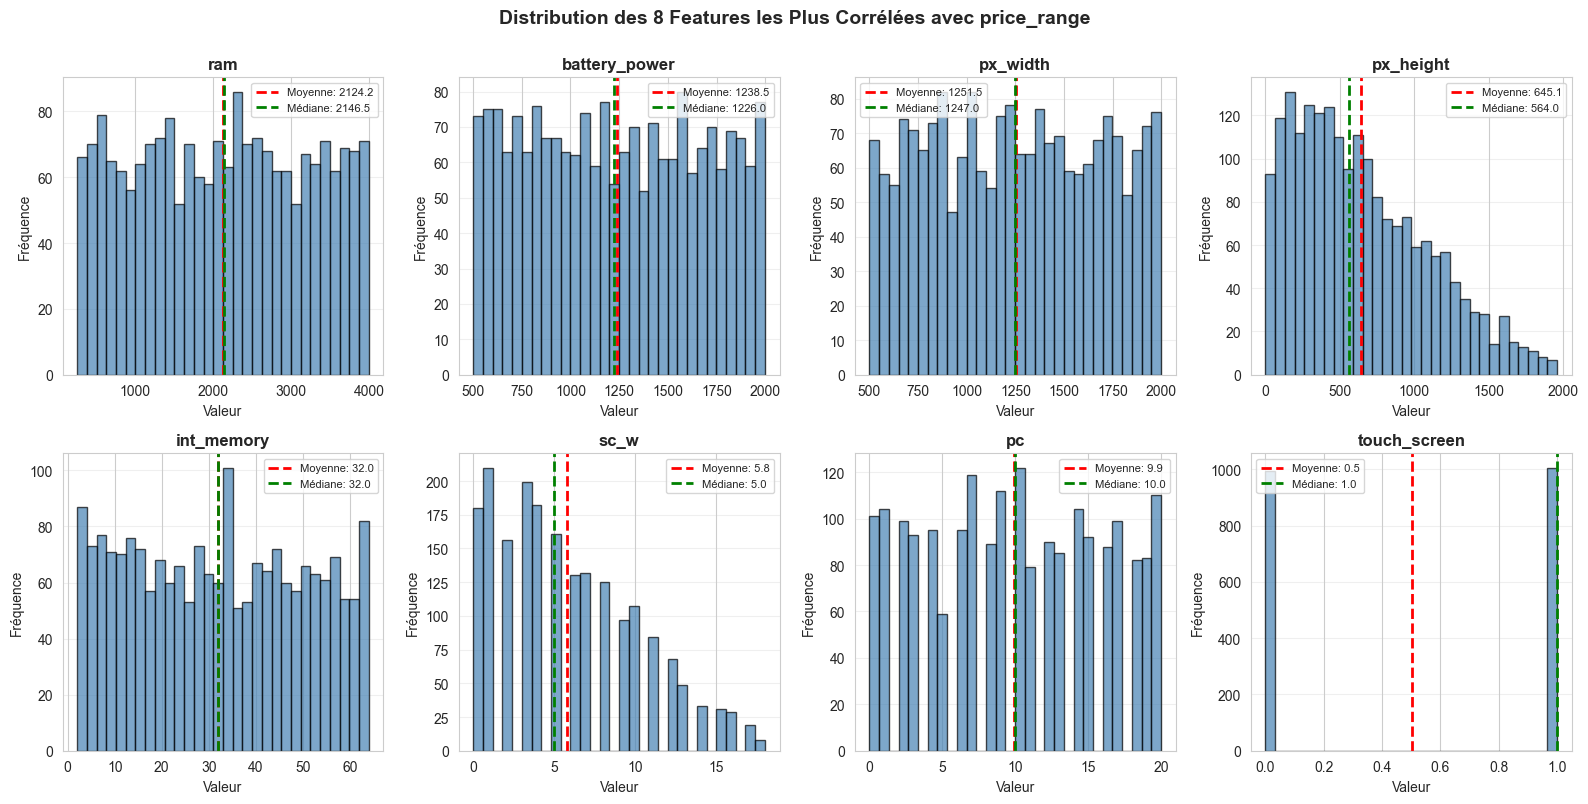

✓ Histogrammes générés avec succès


In [12]:
# Histogrammes des 8 meilleures features corrélées avec la cible
top_8_features = pearson_df.head(8)['Caractéristique'].values

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution des 8 Features les Plus Corrélées avec price_range', 
             fontsize=14, fontweight='bold', y=1.00)

for idx, feature in enumerate(top_8_features):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    # Histogramme avec densité
    ax.hist(df_cleaned[feature], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.grid(axis='y', alpha=0.3)
    
    # Ajouter des statistiques
    mean_val = df_cleaned[feature].mean()
    median_val = df_cleaned[feature].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Médiane: {median_val:.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Histogrammes générés avec succès")

### 4.2 Diagrammes en boîte (Box plots)
Visualisation des distributions par gamme de prix pour les features principales.

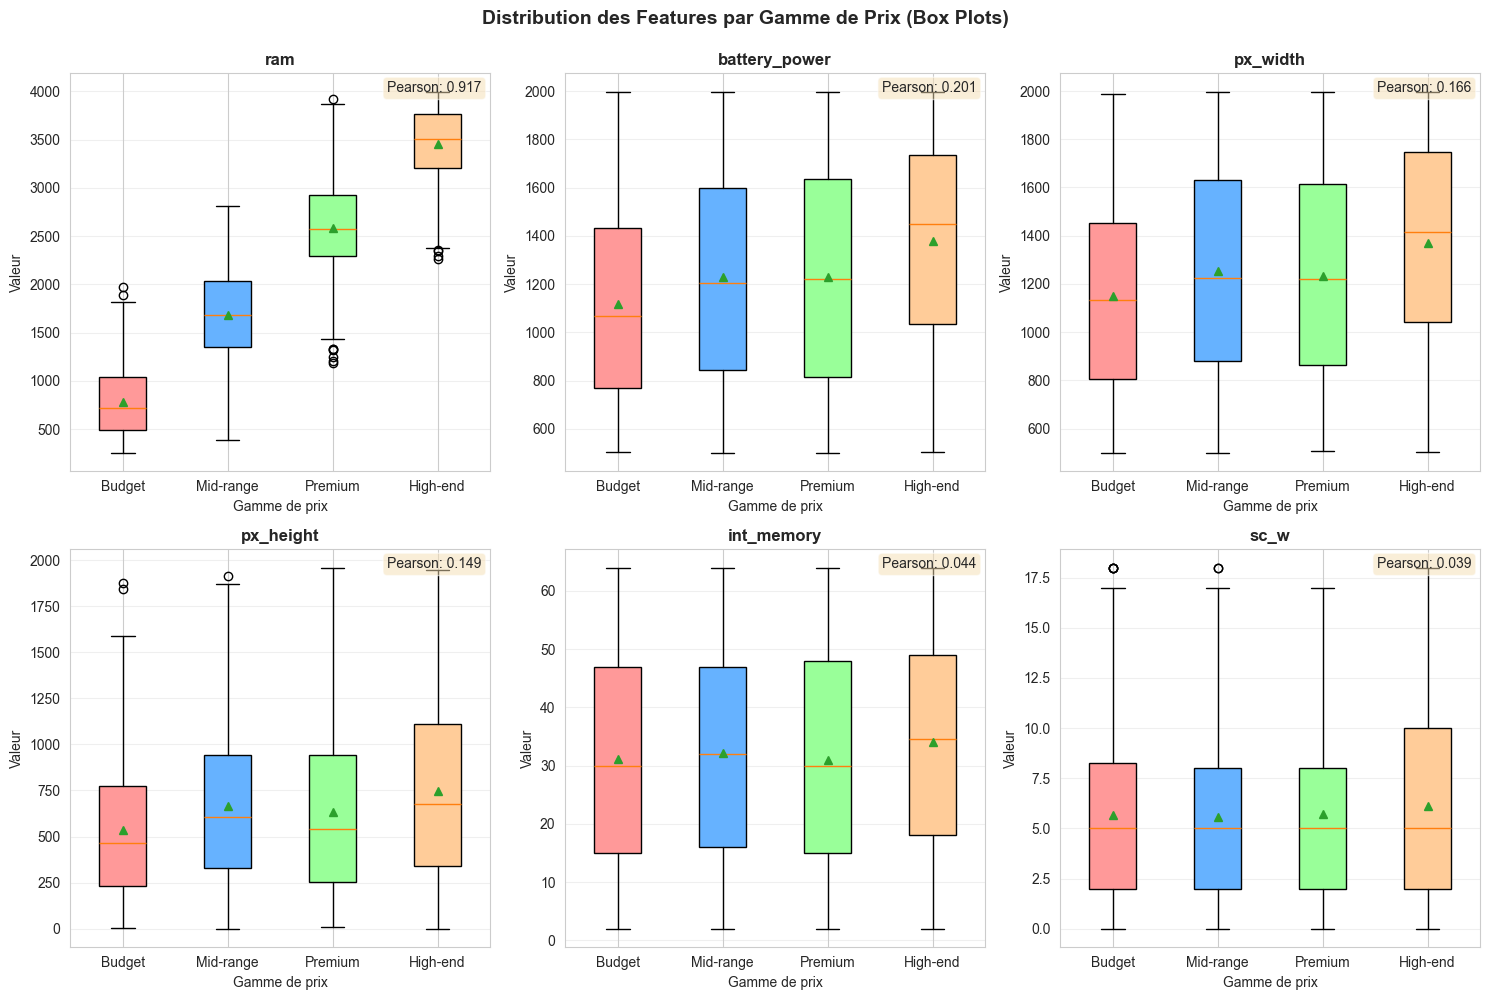

✓ Diagrammes en boîte générés avec succès


In [13]:
# Box plots des 6 meilleures features par gamme de prix
top_6_features = pearson_df.head(6)['Caractéristique'].values

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution des Features par Gamme de Prix (Box Plots)', 
             fontsize=14, fontweight='bold', y=0.995)

for idx, feature in enumerate(top_6_features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Préparer les données pour le box plot
    data_to_plot = [df_cleaned[df_cleaned['price_range'] == i][feature].values 
                    for i in sorted(df_cleaned['price_range'].unique())]
    
    bp = ax.boxplot(data_to_plot, labels=['Budget', 'Mid-range', 'Premium', 'High-end'],
                    patch_artist=True, showmeans=True)
    
    # Colorer les boîtes
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_ylabel('Valeur')
    ax.set_xlabel('Gamme de prix')
    ax.grid(axis='y', alpha=0.3)
    
    # Ajouter la corrélation Pearson
    corr_val = pearson_df[pearson_df['Caractéristique'] == feature]['Corrélation Pearson'].values[0]
    ax.text(0.98, 0.98, f'Pearson: {corr_val:.3f}', transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Diagrammes en boîte générés avec succès")

### 4.3 Nuages de points (Scatter plots)
Visualisation des relations entre les features principales et la variable cible.

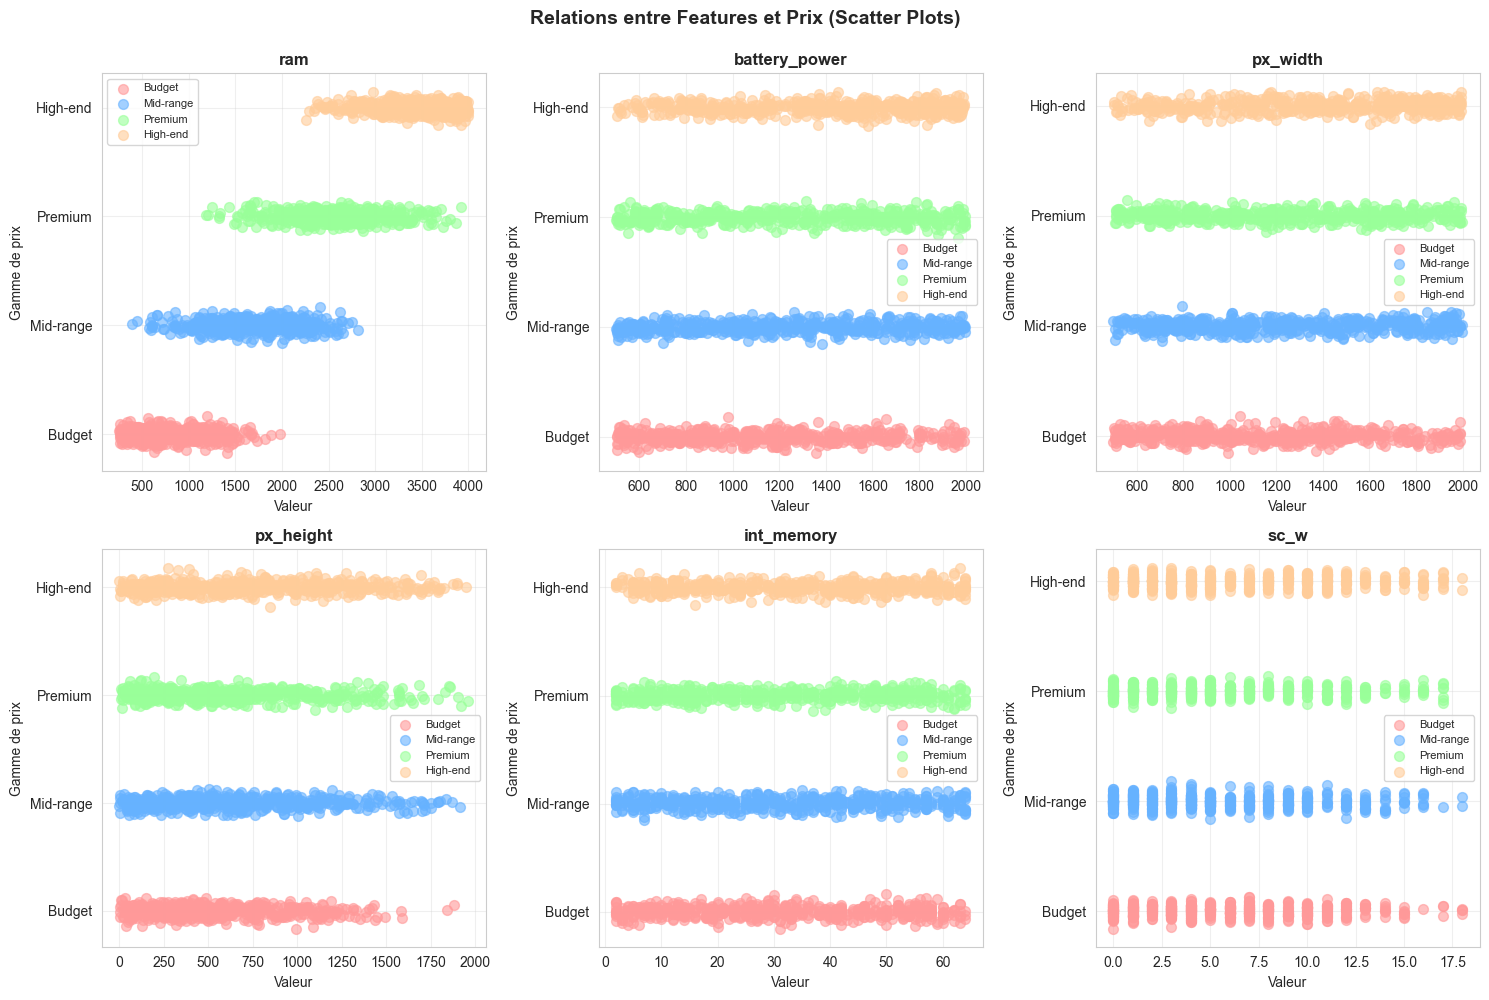

✓ Nuages de points générés avec succès


In [14]:
# Scatter plots des 6 meilleures features vs price_range
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Relations entre Features et Prix (Scatter Plots)', 
             fontsize=14, fontweight='bold', y=0.995)

colors_map = {0: '#FF9999', 1: '#66B2FF', 2: '#99FF99', 3: '#FFCC99'}
price_labels = {0: 'Budget', 1: 'Mid-range', 2: 'Premium', 3: 'High-end'}

for idx, feature in enumerate(top_6_features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Créer un scatter plot pour chaque gamme de prix
    for price_range in sorted(df_cleaned['price_range'].unique()):
        mask = df_cleaned['price_range'] == price_range
        ax.scatter(df_cleaned[mask][feature], 
                  df_cleaned[mask]['price_range'] + np.random.normal(0, 0.05, sum(mask)),
                  alpha=0.6, s=50, color=colors_map[price_range], 
                  label=price_labels[price_range])
    
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Gamme de prix')
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(['Budget', 'Mid-range', 'Premium', 'High-end'])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

print("✓ Nuages de points générés avec succès")

### 4.4 Matrice de corrélation (Heatmap)
Visualisation complète des corrélations entre toutes les variables.


Génération de la matrice de corrélation...


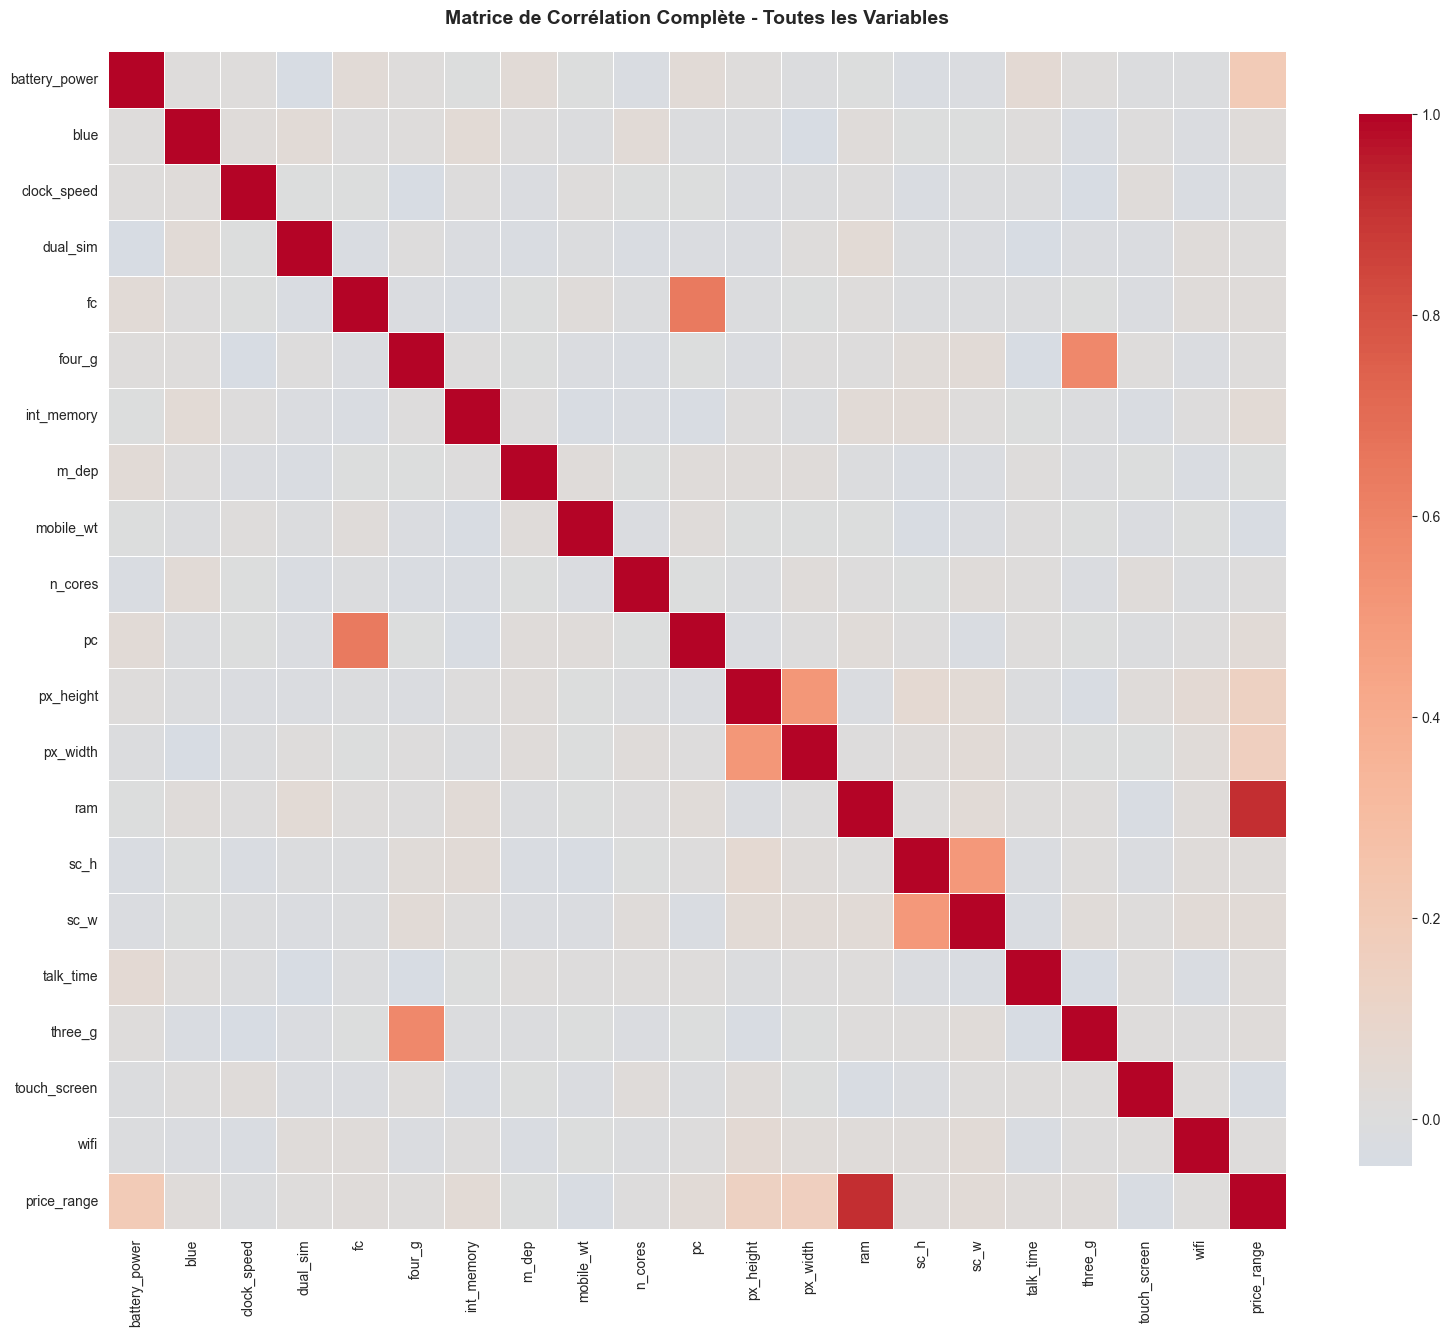

✓ Matrice de corrélation complète générée

Génération d'une heatmap réduite avec les meilleures features...


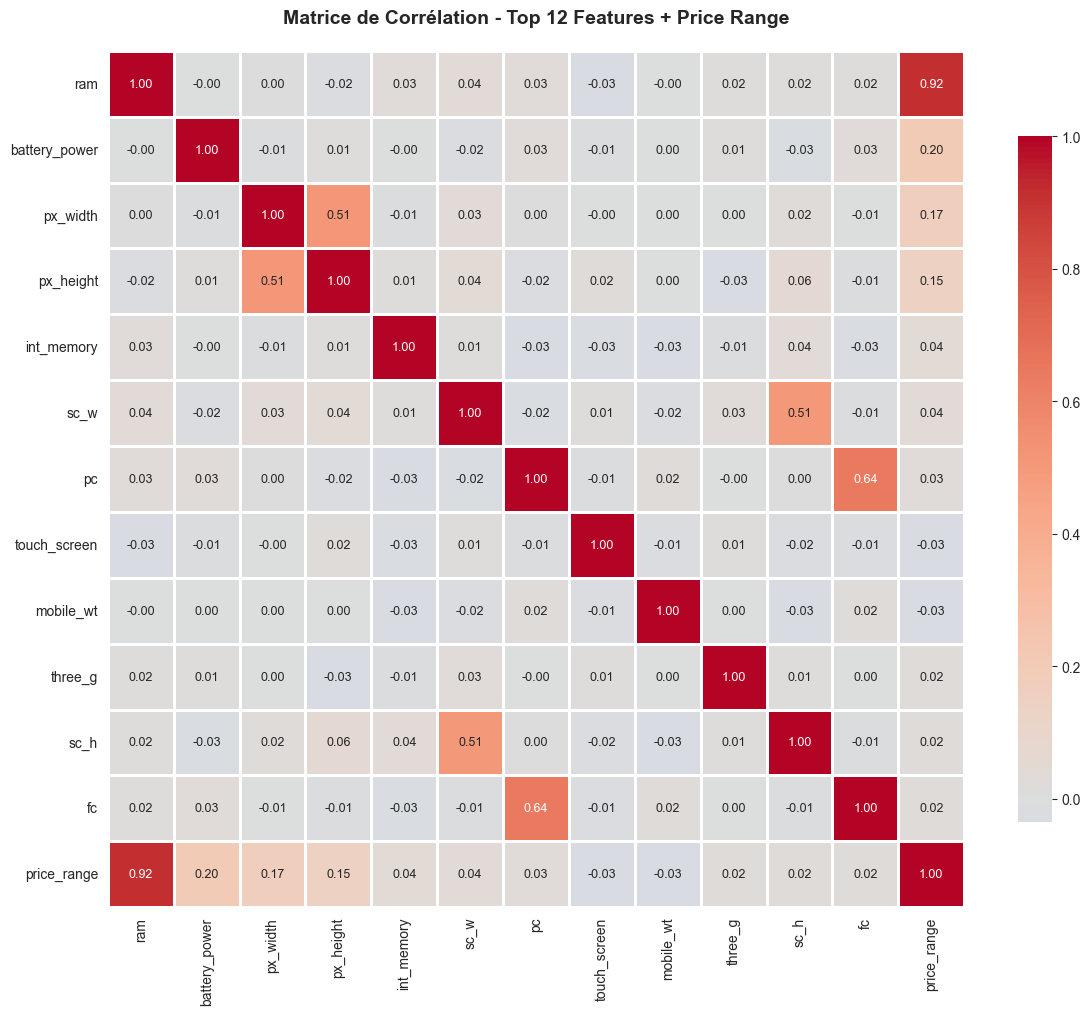

✓ Heatmap réduite générée avec succès


In [15]:
# Matrice de corrélation complète
print("\nGénération de la matrice de corrélation...")

# Calculer la corrélation de Pearson pour toutes les variables
correlation_matrix = df_cleaned.corr()

# Créer une grande heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Heatmap complète
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('Matrice de Corrélation Complète - Toutes les Variables', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("✓ Matrice de corrélation complète générée")

# Heatmap réduite des meilleures features + cible
print("\nGénération d'une heatmap réduite avec les meilleures features...")

top_12_features = list(pearson_df.head(12)['Caractéristique'].values) + ['price_range']
reduced_corr_matrix = df_cleaned[top_12_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(reduced_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax, 
            annot_kws={'fontsize': 9})

ax.set_title('Matrice de Corrélation - Top 12 Features + Price Range', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("✓ Heatmap réduite générée avec succès")

---

## 5. SYNTHÈSE DES IDÉES ET CONCLUSIONS

### 5.1 Résumé des principales découvertes

In [16]:
print("\n" + "=" * 80)
print("SYNTHÈSE DES PRINCIPALES DÉCOUVERTES")
print("=" * 80)

# 1. Top Features corrélés
print("\n📊 1. TOP 5 FEATURES LES PLUS CORRÉLÉS AVEC LA GAMME DE PRIX:")
print("─" * 80)
top_5_features = pearson_df.head(5)
for idx, row in top_5_features.iterrows():
    print(f"   {idx+1}. {row['Caractéristique']:20s} → Corrélation: {row['Corrélation Pearson']:+.4f}")
    print(f"      Force: {row['Force de la relation']}, p-value: {row['p-value']:.2e}")

# 2. Features avec différence significative
print("\n🔍 2. FEATURES AVEC DIFFÉRENCE SIGNIFICATIVE ENTRE GROUPES DE PRIX:")
print("─" * 80)
sig_features = anova_df[anova_df['Significatif (α=0.05)'] == 'Oui'].head(10)
print(f"   Nombre total: {len(anova_df[anova_df['Significatif (α=0.05)'] == 'Oui'])}/{len(features)} features")
print("\n   Top 10 par F-statistique:")
for idx, row in sig_features.sort_values('F-statistique', ascending=False).head(10).iterrows():
    print(f"   • {row['Caractéristique']:20s} → F-stat: {row['F-statistique']:8.2f}, p-value: {row['p-value']:.2e}")

# 3. Distribution des données
print("\n📈 3. CARACTÉRISTIQUES DE LA DISTRIBUTION:")
print("─" * 80)
features_with_skew = skew_kurt_df[skew_kurt_df['Interprétation Asymétrie'] != 'Symétrique'].head(5)
print(f"   • {len(features_with_skew)} features présentent une asymétrie notable")
print(f"   • Top 3 features les plus asymétriques:")
for idx, (_, row) in enumerate(features_with_skew.head(3).iterrows(), 1):
    print(f"     {idx}. {row['Caractéristique']:20s} → Asymétrie: {row['Asymétrie (Skewness)']:+.4f} ({row['Interprétation Asymétrie']})")

# 4. Qualité de la prédiction
print("\n🎯 4. POTENTIEL PRÉDICTIF DES FEATURES:")
print("─" * 80)
strong_corr = pearson_df[abs(pearson_df['Corrélation Pearson']) > 0.5]
print(f"   • {len(strong_corr)} features avec corrélation FORTE (|r| > 0.5)")
moderate_corr = pearson_df[(abs(pearson_df['Corrélation Pearson']) > 0.3) & 
                           (abs(pearson_df['Corrélation Pearson']) <= 0.5)]
print(f"   • {len(moderate_corr)} features avec corrélation MODÉRÉE (0.3 < |r| ≤ 0.5)")
weak_corr = pearson_df[abs(pearson_df['Corrélation Pearson']) <= 0.3]
print(f"   • {len(weak_corr)} features avec corrélation FAIBLE (|r| ≤ 0.3)")

# 5. Différences entre groupes de prix
print("\n💰 5. DIFFÉRENCES ENTRE GROUPES DE PRIX:")
print("─" * 80)
print("   Distribution de la variable cible:")
for price_range in sorted(df_cleaned['price_range'].unique()):
    count = (df_cleaned['price_range'] == price_range).sum()
    pct = count / len(df_cleaned) * 100
    labels_map = {0: 'Budget', 1: 'Mid-range', 2: 'Premium', 3: 'High-end'}
    print(f"   • {labels_map[price_range]:15s}: {count:5d} téléphones ({pct:5.1f}%)")


SYNTHÈSE DES PRINCIPALES DÉCOUVERTES

📊 1. TOP 5 FEATURES LES PLUS CORRÉLÉS AVEC LA GAMME DE PRIX:
────────────────────────────────────────────────────────────────────────────────
   14. ram                  → Corrélation: +0.9170
      Force: Forte, p-value: 0.00e+00
   1. battery_power        → Corrélation: +0.2007
      Force: Faible, p-value: 0.00e+00
   13. px_width             → Corrélation: +0.1658
      Force: Faible, p-value: 0.00e+00
   12. px_height            → Corrélation: +0.1489
      Force: Faible, p-value: 0.00e+00
   7. int_memory           → Corrélation: +0.0444
      Force: Faible, p-value: 4.69e-02

🔍 2. FEATURES AVEC DIFFÉRENCE SIGNIFICATIVE ENTRE GROUPES DE PRIX:
────────────────────────────────────────────────────────────────────────────────
   Nombre total: 7/20 features

   Top 10 par F-statistique:
   • ram                  → F-stat:  3520.11, p-value: 0.00e+00
   • battery_power        → F-stat:    31.60, p-value: 0.00e+00
   • px_width             → F-stat